In [7]:
import numpy as np
import pandas as pd

In [72]:
data = pd.read_csv('https://raw.githubusercontent.com/Himanshu-1703/reddit-sentiment-analysis/refs/heads/main/data/reddit.csv')

In [70]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from imblearn.over_sampling import SMOTE
import optuna
from lightgbm import LGBMClassifier
import warnings
import matplotlib.pyplot as plt

In [67]:
data[data['category'] == -1]

,clean_comment,category
2,seriously don say thing first all they won get...,-1
5,you should all sit down together and watch the...,-1
8,there are two varieties christians dogmatic th...,-1
15,does evil include the lady pai chunked,-1
17,technically you could argue that sobek evil wo...,-1
...,...,...
37184,how else supposed ask for your vote only viola...,-1
37193,modi like trump obsessed who criticizing him m...,-1
37204,fuck you nearly had want rush the atm,-1
37209,seriously the india hasn done any press confer...,-1


In [ ]:
# Step 1 remap the class label from [-1,0,1] to [2,0,1]

print("Category distribution BEFORE remapping:")
print(data['category'].value_counts())

data['category'] = data['category'].map({-1:2,0:0,1:1})

print("\nCategory distribution AFTER remapping (before dropping NaNs in clean_comment):")
print(data['category'].value_counts())

# Step 2: Remove rows where the target labels (category) are NAN (but specifically for clean_comment)
print("\nNumber of rows with NaN in 'clean_comment' for category 2 (original -1) before dropping:")
print(data[data['clean_comment'].isna() & (data['category'] == 2)].shape[0])

initial_shape = data.shape[0]
data = data.dropna(subset=['clean_comment'])
dropped_rows = initial_shape - data.shape[0]

print(f"\nDropped {dropped_rows} rows due to NaN in 'clean_comment'.")
print("Category distribution AFTER dropping NaNs in clean_comment:")
print(data['category'].value_counts())

In [76]:
print(data['category'].value_counts())

category
1    15830
0    13142
2     8277
Name: count, dtype: int64


In [75]:
# Step 1 remap the class label from [-1,0,1] to [2,0,1]

data['category'] = data['category'].map({-1:2,0:0,1:1})

# Step 2: Remove rows where the ttarget labels (category) are NAN
data = data.dropna(subset=['clean_comment'])



In [77]:
# Ensure 'clean_comment' column contains only strings and handle any remaining NaN values.
data['clean_comment'] = data['clean_comment'].astype(str)
data.dropna(subset=['clean_comment'], inplace=True)

In [87]:
# Step 3: TF-IDF vectorized setup
ngram_range = (1,3)  # Trigram
max_features = 1000

vectorizer = TfidfVectorizer(
    ngram_range=ngram_range,
    max_features=max_features
)

x = vectorizer.fit_transform(data['clean_comment'])
y = data['category']
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)


Class distribution of target variable:
category
1    15830
0    13142
2     8277
Name: count, dtype: int64


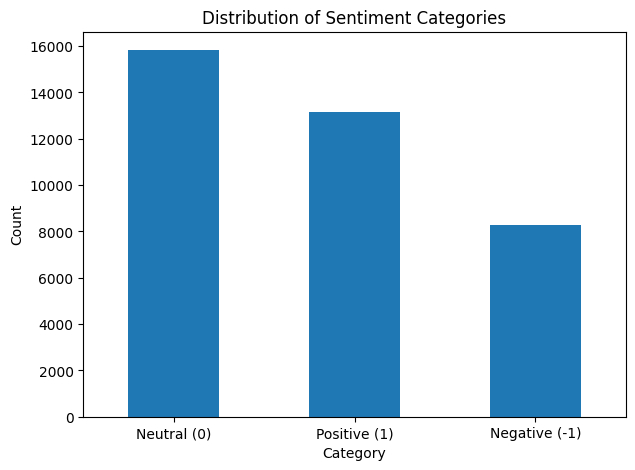

In [79]:
# Check class distribution of the target variable
print('Class distribution of target variable:')
print(y.value_counts())

# Visualize class distribution
plt.figure(figsize=(7, 5))
y.value_counts().plot(kind='bar')
plt.title('Distribution of Sentiment Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['Neutral (0)', 'Positive (1)', 'Negative (-1)'], rotation=0)
plt.show()

In [89]:

X_train, X_test, y_train, y_test = train_test_split(x_resampled,y_resampled, test_size=0.2, random_state=42)


In [92]:
from sklearn.ensemble import RandomForestClassifier

# Step 5: Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Step 6: Make predictions and evaluate
y_pred = rf_model.predict(X_test)

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8178563908191198

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85      3166
           1       0.81      0.78      0.80      3190
           2       0.83      0.78      0.81      3142

    accuracy                           0.82      9498
   macro avg       0.82      0.82      0.82      9498
weighted avg       0.82      0.82      0.82      9498

